# 실습 내용

- 데이터 : diabetes.csv
- 개별 알고리즘으로 모델을 만들어 성능을 확인한다.
- Stacking 앙상블을 사용해 모델을 만들어 성능을 확인한다.

# 1.환경 준비

In [38]:
# 라이브러리 불러오기
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings(action='ignore')
%config InlineBackend.figure_format = 'retina'

In [39]:
path = './../00_data/diabetes.csv'
df = pd.read_csv(path)

# 2.데이터 이해

In [40]:
# 상위 몇 개 행 확인
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [41]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


**데이터설명**

피마 인디언 당뇨 데이터셋은 몇 명의 여성 피마 인디언의 진료 자료와 진단 후 5년 내 당뇨 발병 여부로 구성됨

- Pregnancies: 임신 횟수
- Glucose: 포도당 부하 검사 수치
- BloodPressure: 혈압(mm Hg)
- SkinThickness: 팔 삼두근 뒤쪽의 피하지방 측정값(mm)
- Insulin: 혈청 인슐린(mu U/ml)
- BMI: 체질량지수(체중(kg)/키(m))^2
- DiabetesPedigreeFunction: 당뇨 내력 가중치 값
- Age: 나이
- Outcome: 클래스 결정 값(0 또는 1)

**diabetes**

- 당뇨병(糖尿病, diabetes)은 높은 혈당 수치가 오랜 기간 지속되는 대사 질환이다.
- 혈당이 높을 때의 증상으로는 소변이 잦아지고, 갈증과 배고픔이 심해진다.
- 이를 치료하지 않으면 다른 합병증을 유발할 수 있다.
(출처: 위키백과)

In [42]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


# 3.데이터 전처리

**1) x, y 분리**

In [43]:
target = 'Outcome'

X = df.drop(target, axis=1)
y = df[target]

**2) 학습용, 평가용 데이터 분리**

In [44]:
# 모듈 불러오기
from sklearn.model_selection import train_test_split

# 7:3으로 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

**3) 정규화**

In [45]:
# 모듈 불러오기
from sklearn.preprocessing import MinMaxScaler

# 정규화
scaler = MinMaxScaler()
scaler.fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

# 4.모델링

## 4.1.Decision Tree 모델링

In [46]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import *

model = DecisionTreeClassifier()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

# 성능 정보 수집
result = {}
result['Decision Tree'] = accuracy_score(y_test, y_pred)

[[117  29]
 [ 38  47]]
              precision    recall  f1-score   support

           0       0.75      0.80      0.78       146
           1       0.62      0.55      0.58        85

    accuracy                           0.71       231
   macro avg       0.69      0.68      0.68       231
weighted avg       0.70      0.71      0.71       231



## 4.2.KNN 모델링

In [47]:
# 불러오기
from sklearn.neighbors import KNeighborsClassifier

# 선언하기
model = KNeighborsClassifier()

# 학습하기
model.fit(X_train_s, y_train)

# 예측하기
y_pred = model.predict(X_test_s)

# 평가하기
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

# 성능정보 수집
result['KNN'] = accuracy_score(y_test, y_pred)

[[129  17]
 [ 35  50]]
              precision    recall  f1-score   support

           0       0.79      0.88      0.83       146
           1       0.75      0.59      0.66        85

    accuracy                           0.77       231
   macro avg       0.77      0.74      0.75       231
weighted avg       0.77      0.77      0.77       231



## 4.3.Logistic Regression 모델링

In [48]:
# 불러오기
from sklearn.linear_model import LogisticRegression

# 선언하기
model = LogisticRegression(max_iter=1000)

# 학습하기
model.fit(X_train, y_train)

# 예측하기
y_pred = model.predict(X_test)

# 평가하기
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

# 성능정보 수집
result['Logistic Regression'] = accuracy_score(y_test, y_pred)

[[132  14]
 [ 36  49]]
              precision    recall  f1-score   support

           0       0.79      0.90      0.84       146
           1       0.78      0.58      0.66        85

    accuracy                           0.78       231
   macro avg       0.78      0.74      0.75       231
weighted avg       0.78      0.78      0.78       231



## 4.4.LightGBM 모델링

In [ ]:
from lightgbm import LGBMClassifier

# 선언하기
model = LGBMClassifier(
    min_child_samples=5,        # 리프 노드의 최소 데이터 수(마지막 그룹에 최소 5개 데이터만 있어도 허용). 작게 설정 -> 성능향상 but 과적합위험. 크게 설정 -> 안정적.
    max_depth=20,
    force_col_wise=True,        # 불필요한 자동 선택 과정과 안내 메시지 줄이는 옵션. colum학습을 강제로 지정하는 옵션
    verbose=-1
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

result['LightGBM'] = accuracy_score(y_test, y_pred)

[[127  19]
 [ 32  53]]
              precision    recall  f1-score   support

           0       0.80      0.87      0.83       146
           1       0.74      0.62      0.68        85

    accuracy                           0.78       231
   macro avg       0.77      0.75      0.75       231
weighted avg       0.78      0.78      0.77       231



## 4.5.Stacking 모델링

In [50]:
from sklearn.ensemble import StackingClassifier
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestClassifier

# 모델 설정하기(사용할 모델들을 지정)
estimators = [('lr', make_pipeline(MinMaxScaler(), LogisticRegression())),
              ('knn', make_pipeline(MinMaxScaler(), KNeighborsClassifier())),
              ('dt', DecisionTreeClassifier()),
              ('lgb', LGBMClassifier())]

model =StackingClassifier(estimators=estimators,
                          final_estimator=RandomForestClassifier())

# 학습하기
model.fit(X_train, y_train)

# 예측하기
y_pred = model.predict(X_test)

# 평가하기
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

# 성능정보 수집
result['Stacking'] = accuracy_score(y_test, y_pred)

[[124  22]
 [ 39  46]]
              precision    recall  f1-score   support

           0       0.76      0.85      0.80       146
           1       0.68      0.54      0.60        85

    accuracy                           0.74       231
   macro avg       0.72      0.70      0.70       231
weighted avg       0.73      0.74      0.73       231



# 5.성능 비교

- 위에서 수집한 성능 정보를 시각화해 비교한다.

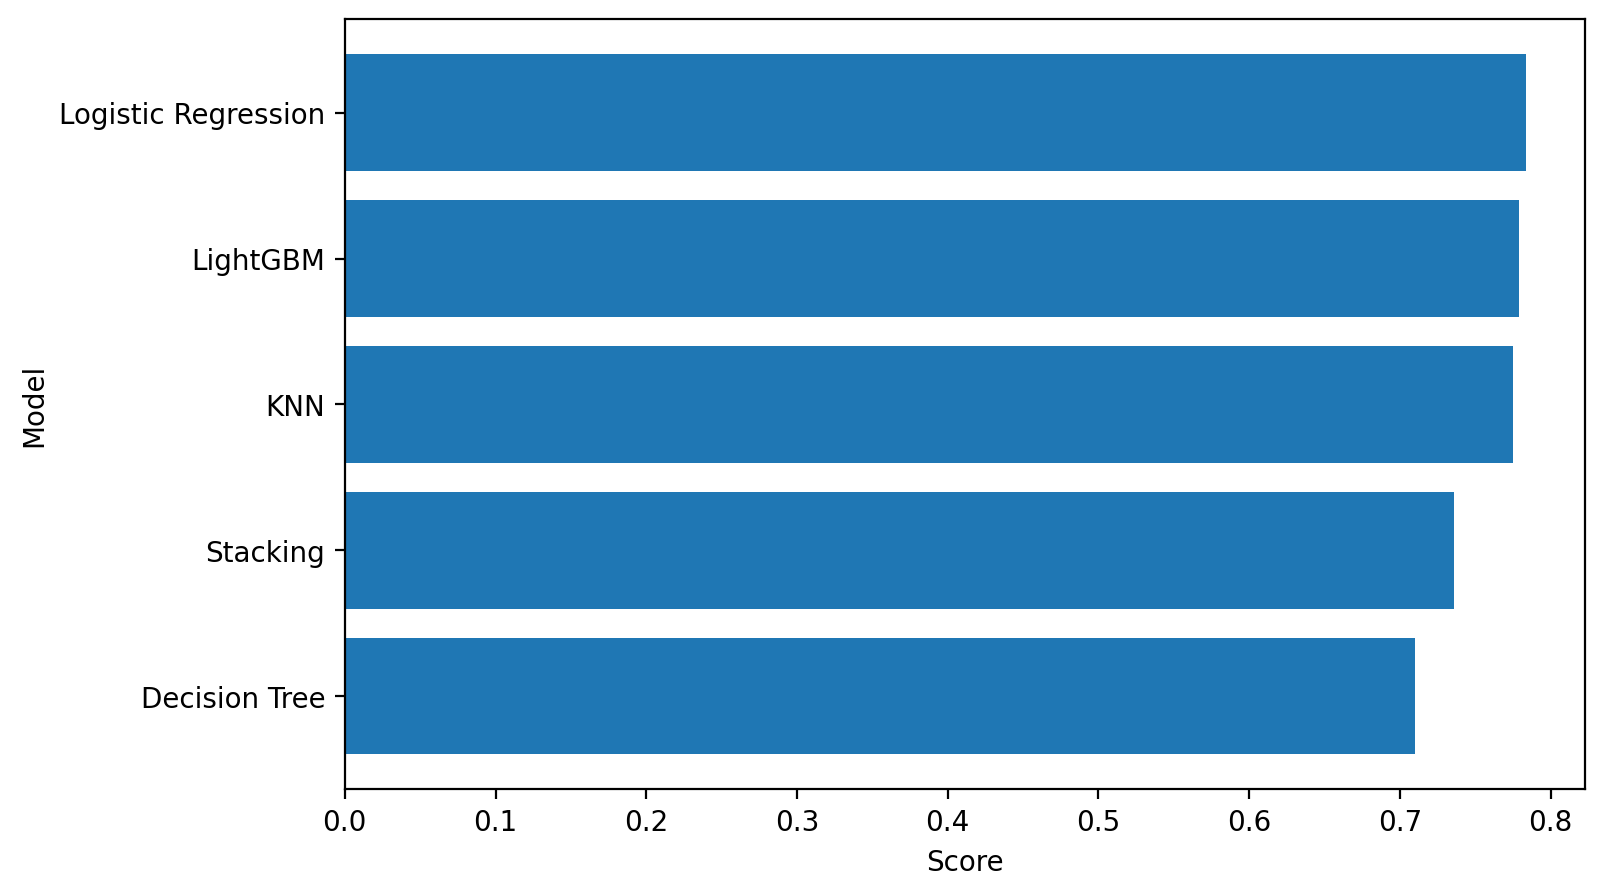

In [52]:
# 데이터프레임 만들기
df_result = pd.DataFrame.from_dict(result, orient='index', columns=['score'])
df_result.sort_values(by='score', ascending=True, inplace=True)

plt.figure(figsize=(8,5))
plt.barh(y=df_result.index, width=df_result['score'])
plt.xlabel('Score')
plt.ylabel('Model')
plt.show()